[*********************100%***********************]  11 of 11 completed


Initializing Baseline Portfolio (Markowitz Optimization)...

Training neural network on data before 2021-06-01...
Epoch [15/60] | Train MSE Loss: 1.2237
Epoch [30/60] | Train MSE Loss: 0.6681
Epoch [45/60] | Train MSE Loss: 0.4854
Epoch [60/60] | Train MSE Loss: 0.3897

Starting Active Trading Simulation from 2021-06-01 to 2026-06-12...

METRIC                    | ML PORTFOLIO    | S&P 500 (SPY)  
-----------------------------------------------------------------
Cumulative Return         |          93.87% |          88.06%
Annualized Return (CAGR)  |          14.11% |          13.42%
Annualized Volatility     |          14.99% |          17.07%
Sharpe Ratio              |           0.94  |           0.79 
Sortino Ratio             |           1.32  |           1.08 
Maximum Drawdown          |         -15.33% |         -24.50%
Daily Win Rate            |          54.35% |          54.51%

Generating Analytics Dashboard...


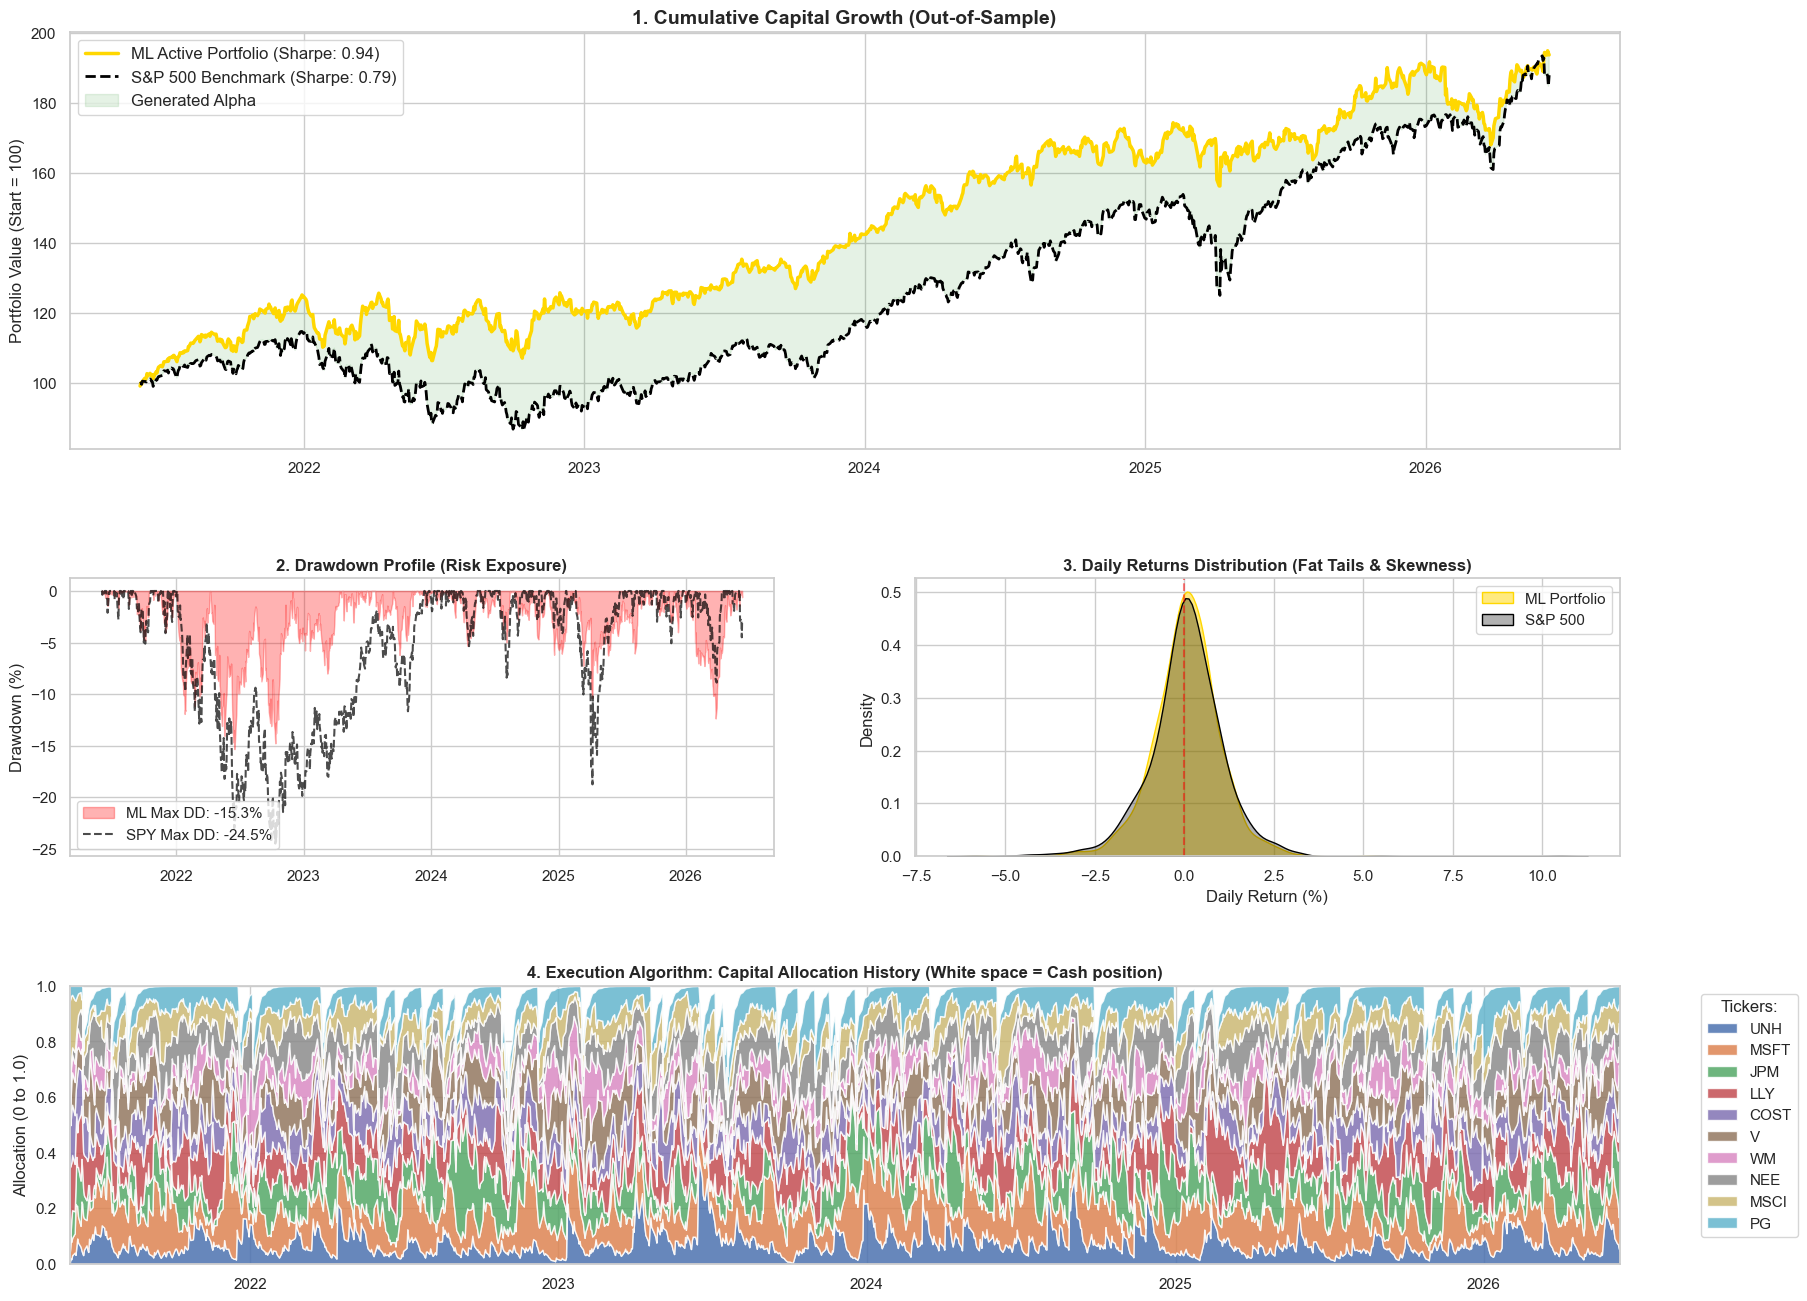

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from pypfopt import EfficientFrontier, risk_models, expected_returns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# =========================================================
# 0. CONFIGURATION & DATES (MANUAL INPUT)
# =========================================================
# Set the start date for training the neural network
TRAIN_START = "2020-01-01" 

# Set the active trading simulation period (Out-of-Sample)
SIMULATION_START = "2021-06-01"
SIMULATION_END = "2026-06-12"

SEQ_LENGTH = 60
TICKERS = ["UNH", "MSFT", "JPM", "LLY", "COST", "V", "WM", "NEE", "MSCI", "PG"]

# =========================================================
# 1. DATA ACQUISITION & PREPARATION
# =========================================================
print(f"Downloading data from {TRAIN_START} to {SIMULATION_END}...")
raw_data = yf.download(TICKERS + ["SPY"], start=TRAIN_START, end=SIMULATION_END, auto_adjust=True)['Close'].dropna()

spy_prices = raw_data['SPY']
stock_prices = raw_data.drop(columns=['SPY'])

# Calculate daily returns and scale by 100 for percentage format
returns = stock_prices.pct_change().dropna() * 100
spy_returns = spy_prices.pct_change().dropna() * 100

# Align indices to prevent dimension mismatches
returns, spy_returns = returns.align(spy_returns, join='inner', axis=0)

# =========================================================
# 2. INITIALIZE BASELINE PORTFOLIO (Markowitz Optimization)
# =========================================================
print("Initializing Baseline Portfolio (Markowitz Optimization)...")
# Isolate training data strictly to avoid data leakage during optimization
train_data_for_opt = stock_prices[:SIMULATION_START].iloc[:-1] 

mu = expected_returns.mean_historical_return(train_data_for_opt)
S = risk_models.sample_cov(train_data_for_opt)
ef = EfficientFrontier(mu, S)

raw_weights = ef.max_sharpe()
cleaned_weights = ef.clean_weights()

# Create static weight vector for the baseline portfolio
static_weights = np.array([cleaned_weights.get(t, 0) for t in TICKERS])

# =========================================================
# 3. FEATURE ENGINEERING & TRAIN/TEST SPLIT
# =========================================================
scaler = StandardScaler()
# Scale returns and clip outliers to stabilize neural network training
scaled_returns = np.clip(scaler.fit_transform(returns.values), -3, 3)

NUM_ASSETS = len(TICKERS)
xs, ys_future_ret = [], []
valid_dates = returns.index[SEQ_LENGTH:]

for i in range(len(scaled_returns) - SEQ_LENGTH):
    xs.append(scaled_returns[i : i + SEQ_LENGTH])
    # Target: The actual return of each asset on day T+1
    ys_future_ret.append(returns.values[i + SEQ_LENGTH])

X = torch.tensor(np.array(xs), dtype=torch.float32)
Y_ret = torch.tensor(np.array(ys_future_ret), dtype=torch.float32)

# Create boolean masks based on the user-defined date parameters
train_mask = valid_dates < SIMULATION_START
test_mask = (valid_dates >= SIMULATION_START) & (valid_dates <= SIMULATION_END)

X_train, Y_train = X[train_mask], Y_ret[train_mask]
X_test, Y_test = X[test_mask], Y_ret[test_mask]

test_dates = valid_dates[test_mask]
spy_test_returns = spy_returns.values[SEQ_LENGTH:][test_mask]

train_loader = DataLoader(TensorDataset(X_train, Y_train), batch_size=64, shuffle=True)

# =========================================================
# 4. NEURAL NETWORK ARCHITECTURE
# =========================================================
class AssetReturnPredictor(nn.Module):
    def __init__(self, num_assets, seq_length):
        super(AssetReturnPredictor, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(num_assets * seq_length, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.01),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.01),
            nn.Linear(64, num_assets) 
        )
        
    def forward(self, x):
        return self.net(x.view(x.size(0), -1))

# =========================================================
# 5. MODEL TRAINING
# =========================================================
model = AssetReturnPredictor(num_assets=NUM_ASSETS, seq_length=SEQ_LENGTH)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

EPOCHS = 60
print(f"\nTraining neural network on data before {SIMULATION_START}...")
for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0.0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(batch_x), batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        
    if (epoch + 1) % 15 == 0:
        print(f"Epoch [{epoch+1}/{EPOCHS}] | Train MSE Loss: {epoch_loss/len(train_loader):.4f}")

# =========================================================
# 6. TRADING SIMULATOR (Out-of-Sample)
# =========================================================
print(f"\nStarting Active Trading Simulation from {SIMULATION_START} to {SIMULATION_END}...")
model.eval()

# Start with the baseline optimized weights
current_ml_weights = np.copy(static_weights)
weights_history = []

ml_daily_returns_list = []
static_daily_returns_list = []
spy_daily_returns_list = []

with torch.no_grad():
    for i in range(len(X_test)):
        # Predict tomorrow's return for each asset
        pred_returns = model(X_test[i:i+1]).numpy()[0]
        
        # Determine target portfolio allocation
        target_weights = np.zeros(NUM_ASSETS)
        positive_indices = pred_returns > 0
        
        # Only buy assets with a predicted positive return
        if np.any(positive_indices):
            target_weights[positive_indices] = pred_returns[positive_indices] / np.sum(pred_returns[positive_indices])

        # Smooth the transition (20% rebalancing per day to mitigate turnover costs/volatility)
        current_ml_weights = 0.8 * current_ml_weights + 0.2 * target_weights
        weights_history.append(current_ml_weights)
        
        # Calculate the actual return of the portfolio for the day
        actual_daily_returns = Y_test[i].numpy() / 100.0
        
        ml_daily_returns_list.append(np.dot(current_ml_weights, actual_daily_returns))
        static_daily_returns_list.append(np.dot(static_weights, actual_daily_returns))
        spy_daily_returns_list.append(spy_test_returns[i] / 100.0)

# Convert lists to pandas Series
ml_ret_series = pd.Series(ml_daily_returns_list, index=test_dates)
spy_ret_series = pd.Series(spy_daily_returns_list, index=test_dates)

# Cumulative capital trajectory (Base = 100)
ml_cum_returns = (1 + ml_ret_series).cumprod() * 100
spy_cum_returns = (1 + spy_ret_series).cumprod() * 100

df_weights = pd.DataFrame(weights_history, index=test_dates, columns=TICKERS)

# =========================================================
# 7. QUANTITATIVE METRICS & TEARSHEET
# =========================================================
def calculate_metrics(returns_series):
    cum_ret = (1 + returns_series).prod() - 1
    years = len(returns_series) / 252
    cagr = (1 + cum_ret) ** (1 / years) - 1 if years > 0 else 0
    volatility = returns_series.std() * np.sqrt(252)
    sharpe = cagr / volatility if volatility > 0 else 0
    
    roll_max = (1 + returns_series).cumprod().cummax()
    drawdown = ((1 + returns_series).cumprod() - roll_max) / roll_max
    max_dd = drawdown.min()
    
    downside_returns = returns_series[returns_series < 0]
    downside_vol = downside_returns.std() * np.sqrt(252)
    sortino = cagr / downside_vol if downside_vol > 0 else 0
    
    win_rate = (returns_series > 0).mean()
    
    return cum_ret, cagr, volatility, sharpe, max_dd, sortino, win_rate, drawdown

ml_cum, ml_cagr, ml_vol, ml_sharpe, ml_mdd, ml_sortino, ml_win, ml_dd_series = calculate_metrics(ml_ret_series)
spy_cum, spy_cagr, spy_vol, spy_sharpe, spy_mdd, spy_sortino, spy_win, spy_dd_series = calculate_metrics(spy_ret_series)

label_sharpe = "Sharpe Ratio"

print("\n" + "="*65)
print(f"{'METRIC':<25} | {'ML PORTFOLIO':<15} | {'S&P 500 (SPY)':<15}")
print("-" * 65)
print(f"{'Cumulative Return':<25} | {ml_cum*100:>14.2f}% | {spy_cum*100:>14.2f}%")
print(f"{'Annualized Return (CAGR)':<25} | {ml_cagr*100:>14.2f}% | {spy_cagr*100:>14.2f}%")
print(f"{'Annualized Volatility':<25} | {ml_vol*100:>14.2f}% | {spy_vol*100:>14.2f}%")
print(f"{label_sharpe:<25} | {ml_sharpe:>14.2f}  | {spy_sharpe:>14.2f} ")
print(f"{'Sortino Ratio':<25} | {ml_sortino:>14.2f}  | {spy_sortino:>14.2f} ")
print(f"{'Maximum Drawdown':<25} | {ml_mdd*100:>14.2f}% | {spy_mdd*100:>14.2f}%")
print(f"{'Daily Win Rate':<25} | {ml_win*100:>14.2f}% | {spy_win*100:>14.2f}%")
print("="*65)

# =========================================================
# 8. VISUALIZATION DASHBOARD
# =========================================================
print("\nGenerating Analytics Dashboard...")
fig = plt.figure(figsize=(20, 16))
import matplotlib.gridspec as gridspec
gs = gridspec.GridSpec(3, 2, height_ratios=[1.5, 1, 1], hspace=0.4, wspace=0.2)

# --- PLOT 1: Cumulative Equity Curve ---
ax0 = plt.subplot(gs[0, :])
ax0.plot(ml_cum_returns.index, ml_cum_returns, color='gold', lw=2.5, label=f'ML Active Portfolio (Sharpe: {ml_sharpe:.2f})')
ax0.plot(spy_cum_returns.index, spy_cum_returns, color='black', linestyle='--', lw=2, label=f'S&P 500 Benchmark (Sharpe: {spy_sharpe:.2f})')
ax0.set_title("1. Cumulative Capital Growth (Out-of-Sample)", fontweight='bold', fontsize=14)
ax0.set_ylabel("Portfolio Value (Start = 100)")
ax0.fill_between(ml_cum_returns.index, ml_cum_returns, spy_cum_returns, 
                 where=(ml_cum_returns > spy_cum_returns), interpolate=True, color='green', alpha=0.1, label='Generated Alpha')
ax0.legend(loc='upper left', fontsize=12)

# --- PLOT 2: Drawdown Profile ---
ax1 = plt.subplot(gs[1, 0])
ax1.fill_between(ml_dd_series.index, ml_dd_series * 100, 0, color='red', alpha=0.3, label=f'ML Max DD: {ml_mdd*100:.1f}%')
ax1.plot(spy_dd_series.index, spy_dd_series * 100, color='black', linestyle='--', alpha=0.7, label=f'SPY Max DD: {spy_mdd*100:.1f}%')
ax1.set_title("2. Drawdown Profile (Risk Exposure)", fontweight='bold')
ax1.set_ylabel("Drawdown (%)")
ax1.legend(loc='lower left')

# --- PLOT 3: Daily Returns Distribution ---
ax2 = plt.subplot(gs[1, 1])
sns.kdeplot(ml_ret_series * 100, ax=ax2, color='gold', fill=True, label='ML Portfolio', alpha=0.5)
sns.kdeplot(spy_ret_series * 100, ax=ax2, color='black', fill=True, label='S&P 500', alpha=0.3)
ax2.axvline(0, color='red', linestyle='--', alpha=0.5)
ax2.set_title("3. Daily Returns Distribution (Fat Tails & Skewness)", fontweight='bold')
ax2.set_xlabel("Daily Return (%)")
ax2.set_ylabel("Density")
ax2.legend()

# --- PLOT 4: Dynamic Capital Allocation ---
ax3 = plt.subplot(gs[2, :])
ax3.stackplot(test_dates, df_weights.T, labels=TICKERS, alpha=0.85, cmap='tab10')
ax3.set_title("4. Execution Algorithm: Capital Allocation History (White space = Cash position)", fontweight='bold')
ax3.set_ylabel("Allocation (0 to 1.0)")
ax3.margins(x=0)
ax3.set_ylim(0, 1)
ax3.legend(loc='upper right', bbox_to_anchor=(1.12, 1), title="Tickers:")

plt.show()